### Setup and Load Data

Project uses the Drug Review Dataset (Druglib.com) from UCI Machine Learning Repository, provided 2 pre-split TSV files: training set (75%) and test set(25%). Train dataset consists of 3107 rows and 9 columns, test dataset consists of 1036 rows and 9 columns. Total dataset size was 4143 reviews.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from wordcloud import WordCloud

sn.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load train and test sets
train_df = pd.read_csv('../data/drugLibTrain_raw.tsv', sep='\t')
test_df = pd.read_csv('../data/drugLibTest_raw.tsv', sep='\t')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3107, 9)
Test shape: (1036, 9)


### Check Basic Structure
Dataset consists of 9 columns documented by UCI: reviewID, urlDrugName, rating, effectiveness, sideEffects, condition, benefitsReview, sideEffectsReview, and commentsReview.

Upon load, reviewID column appeared without header (Unnamed: 0), header was renamed accordingly. Data types show that rating is numeric while effectiveness, sideEffects, and condition are categorical, and the three review fields are free text (object dtype).

In [145]:
train_df.rename(columns={'Unnamed: 0': 'reviewID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0': 'reviewID'}, inplace=True)

print("\nColumns:", list(train_df.columns))
print("\nData types:\n", train_df.dtypes)
train_df.head()


Columns: ['reviewID', 'urlDrugName', 'rating', 'effectiveness', 'sideEffects', 'condition', 'benefitsReview', 'sideEffectsReview', 'commentsReview']

Data types:
 reviewID             int64
urlDrugName            str
rating               int64
effectiveness          str
sideEffects            str
condition              str
benefitsReview         str
sideEffectsReview      str
commentsReview         str
dtype: object


,reviewID,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Review ID Unqiueness Check
Both train and test sets shows reviewIDs are fully unique - 3107 uniqueIDs out of 3107 rows in train set and 1036 unqiueIDs out of 1036 rows in test set, with 0 duplicates. This confirms each row represents a distinct patient with no repeated entries.

In [146]:
print("Train Set Unique reviewIDs:", train_df['reviewID'].nunique(), "out of", len(train_df))
print("Any duplicates?", train_df['reviewID'].duplicated().sum())

print("Test Set Unique reviewIDs:", test_df['reviewID'].nunique(), "out of", len(test_df))
print("Any duplicates?", test_df['reviewID'].duplicated().sum())

Train Set Unique reviewIDs: 3107 out of 3107
Any duplicates? 0
Test Set Unique reviewIDs: 1036 out of 1036
Any duplicates? 0


### Missing Value Check
Missing values were found mainly in free-text fields: benefitsReview (18 missing in train, 5 missing in test), sideEffectsReview (75 missing in train, 23 missing in test) and commentsReview (12 missing in train, 1 missing in test). The condition field had only 1 missing value in training set. All missing counts represents less than 3% of total rows, indicating dataset is largely complete. No fully empty strings were detected beyond the NaN values already captured. No duplicate rows were found, and no reviewID overlap exists between train and test sets, confirming there is no data leakage between the two partitions. 

These missing values will be addressed in the Data Preparation phase on a per-model basis, since each model uses a different text column.

In [147]:
# Missing value check
def missing_summary(df, name):
    missing_count = df.isnull().sum()
    missing_pct = (missing_count / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'Missing Count': missing_count,
        'Missing %': missing_pct
    })
    summary = summary[summary['Missing Count'] > 0]  # only show columns with missing values
    print(f"Missing values ({name}):")
    if summary.empty:
        print("No missing values found.\n")
    else:
        print(summary, "\n")
    return summary

train_missing = missing_summary(train_df, "train")
test_missing = missing_summary(test_df, "test")

print()

# Check empty string that skipped missing value check
text_cols = ['benefitsReview', 'sideEffectsReview', 'commentsReview']
for col in text_cols:
    empty_count = (train_df[col].astype(str).str.strip() == '').sum()
    print(f"Empty strings in {col}: {empty_count}")

# Check duplicated row
print("\nDuplicate rows in train:", train_df.duplicated().sum())

# Check no overlap in reviewID to prevent data leakage
overlap = set(train_df['reviewID']) & set(test_df['reviewID'])
print("Overlapping reviewIDs between train/test:", len(overlap))

Missing values (train):
                   Missing Count  Missing %
condition                      1       0.03
benefitsReview                18       0.58
sideEffectsReview             75       2.41
commentsReview                12       0.39 

Missing values (test):
                   Missing Count  Missing %
benefitsReview                 5       0.48
sideEffectsReview             23       2.22
commentsReview                 1       0.10 


Empty strings in benefitsReview: 0
Empty strings in sideEffectsReview: 0
Empty strings in commentsReview: 0

Duplicate rows in train: 0
Overlapping reviewIDs between train/test: 0


### Variable Distributions
**Effectiveness:** The effectiveness variable is imbalanced, with "Highly Effective" (42.81%) and "Considerably Effective" (29.87%) together accounting for over 72% of all reviews. The remaining three categories, "Moderately Effective" (13.36%), "Ineffective" (7.95%), and "Marginally Effective" (6.02%) are considerably underrepresented.

**Side Effects:** The sideEffects variable is more evenly distributed than effectiveness, though still skewed toward milder outcomes: "Mild Side Effects" (32.80%) and "No Side Effects" (29.93%) together make up roughly 63% of reviews, while "Moderate" (19.76%), "Severe" (11.88%), and "Extremely Severe" (5.63%) side effects are progressively rarer.

**Overall Rating:** The rating variable (1–10 scale) has a mean of 7.01 and median of 8.0 (IQR: 5–9), with a skewness of -0.87, indicating a left (negative) skew — most patients rate their drug experience favorably, with a longer tail toward low ratings rather than a symmetric spread. This aligns with the effectiveness distribution above and reinforces that satisfaction bias is present across all three target variables in this dataset.

**Possible Shared Bias:** The skew observed in effectiveness (favoring "Highly Effective"), side effects (favoring "Mild"/"No Side Effects") and overall rating (skewness = -0.87) may share a common underlying cause: survivourship bias in who leaves a review. Patient who experiencing poor effectiveness, severe side effects and lower overall satisfaction may discontinue the drug and disengage from the trial before writing a review. While those with tolerable or positive experiences are more likely to complete their treatment and leave a review. This would cause underrepresent of negative outcomes in dataset. However, this remained as a hypothesis rather than a confirmed cause, the pattern could reflect genuine population-level trends or mix of both effects. This dataset does not include timestamps and discontinuation flags needed to tackle this, this is a limitation to be revisited. 

**Conclusion:** All three target variables show a positive/favorable skew, which is an important limitation to state explicitly in the report — the model may generalize less well to negative or rare experiences simply because there's less data to learn from in those categories

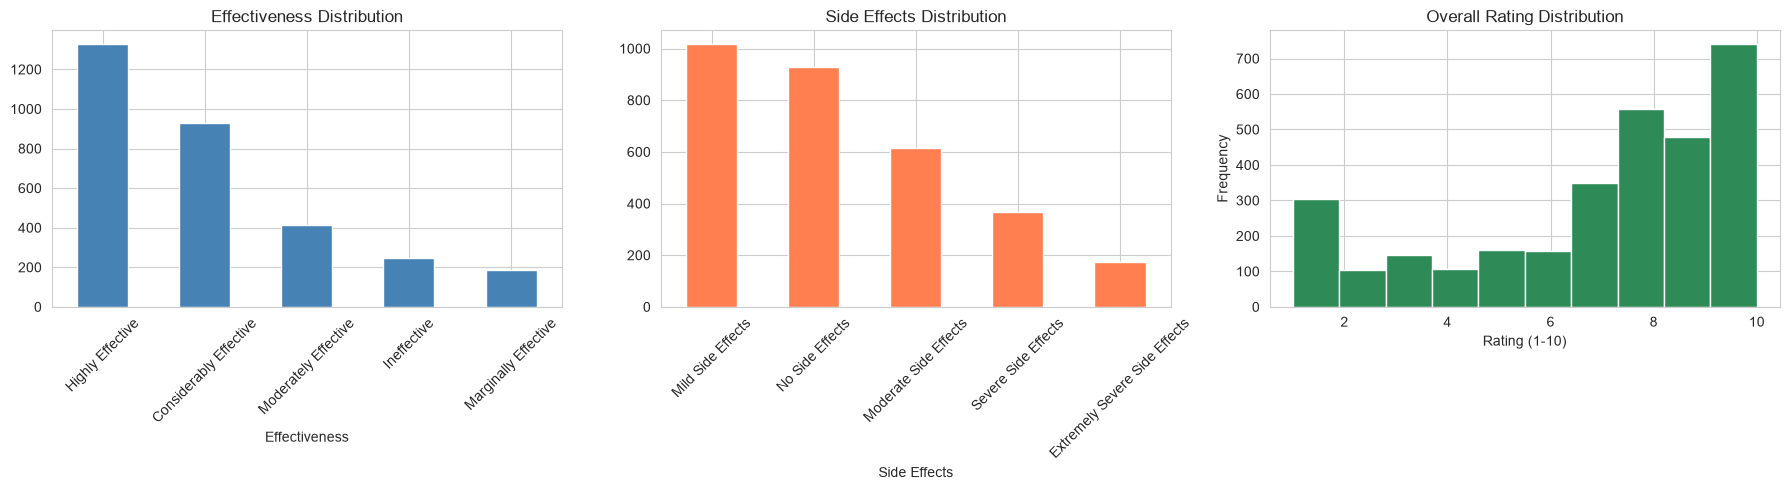

EFFECTIVENESS DISTRIBUTION
                        Count  Percentage
effectiveness                            
Highly Effective         1330       42.81
Considerably Effective    928       29.87
Moderately Effective      415       13.36
Ineffective               247        7.95
Marginally Effective      187        6.02

SIDE EFFECTS DISTRIBUTION
                               Count  Percentage
sideEffects                                     
Mild Side Effects               1019       32.80
No Side Effects                  930       29.93
Moderate Side Effects            614       19.76
Severe Side Effects              369       11.88
Extremely Severe Side Effects    175        5.63

RATING DISTRIBUTION (Descriptive Stats)
count    3107.000000
mean        7.006115
std         2.937582
min         1.000000
25%         5.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: rating, dtype: float64

Rating skewness: -0.87


In [148]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df['effectiveness'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Effectiveness Distribution')
axes[0].set_xlabel('Effectiveness')
axes[0].tick_params(axis='x', rotation=45)

train_df['sideEffects'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Side Effects Distribution')
axes[1].set_xlabel('Side Effects')
axes[1].tick_params(axis='x', rotation=45)

train_df['rating'].plot(kind='hist', bins=10, ax=axes[2], color='seagreen')
axes[2].set_title('Overall Rating Distribution')
axes[2].set_xlabel('Rating (1-10)')

plt.tight_layout()
plt.savefig('../visuals/target_distributions.png', dpi=150)
plt.show()


# Printed Summary
print("=" * 50)
print("EFFECTIVENESS DISTRIBUTION")
print("=" * 50)
eff_counts = train_df['effectiveness'].value_counts()
eff_pct = train_df['effectiveness'].value_counts(normalize=True) * 100
eff_summary = pd.DataFrame({'Count': eff_counts, 'Percentage': eff_pct.round(2)})
print(eff_summary)

print("\n" + "=" * 50)
print("SIDE EFFECTS DISTRIBUTION")
print("=" * 50)
se_counts = train_df['sideEffects'].value_counts()
se_pct = train_df['sideEffects'].value_counts(normalize=True) * 100
se_summary = pd.DataFrame({'Count': se_counts, 'Percentage': se_pct.round(2)})
print(se_summary)

print("\n" + "=" * 50)
print("RATING DISTRIBUTION (Descriptive Stats)")
print("=" * 50)
print(train_df['rating'].describe())

print("\nRating skewness:", round(train_df['rating'].skew().item(), 3))

### Review Length
Word count analysis shows that benefitsReview has a mean length of 36.33 words (range: 0-394), sideEffectsReview averages 31.75 words (range: 0-478) and commentsReview averages 49.78 (range: 0-740). This confirms the text fields contain sufficient depth for meaningful text mining. 

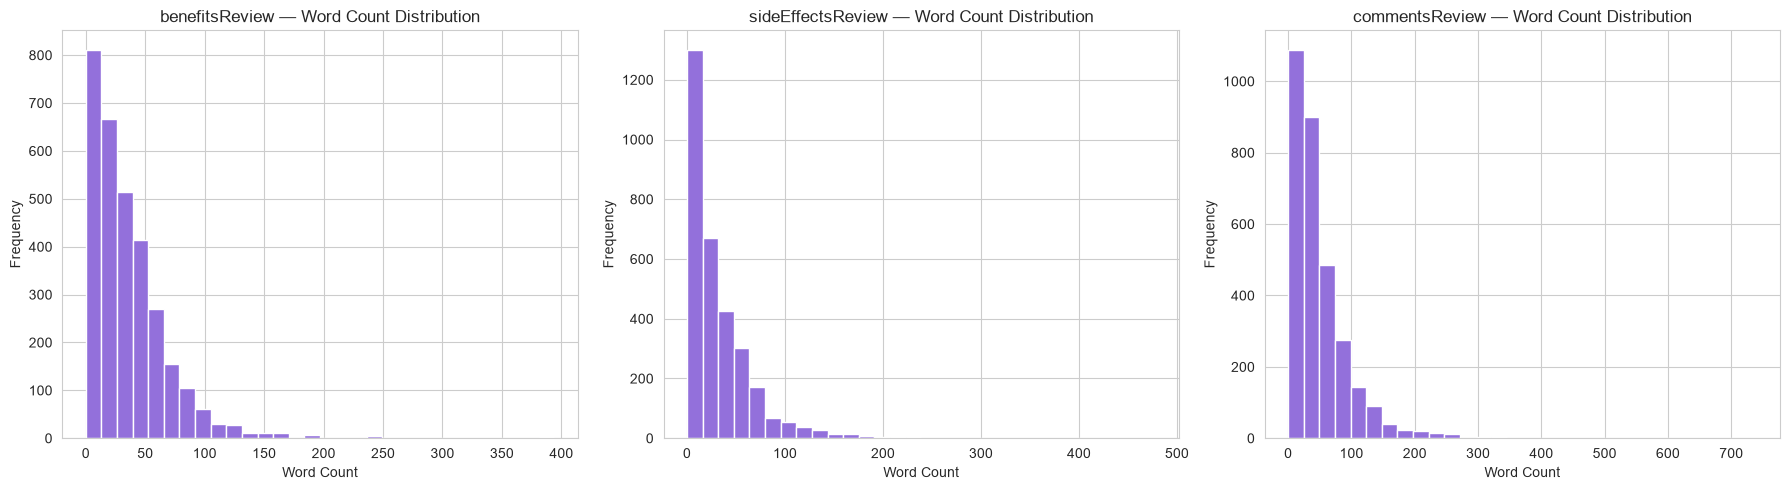

       benefitsReview_length  sideEffectsReview_length  commentsReview_length
count            3107.000000               3107.000000            3107.000000
mean               36.330222                 31.754425              49.781139
std                34.512058                 36.157502              51.157438
min                 0.000000                  0.000000               0.000000
25%                13.000000                  7.000000              18.000000
50%                28.000000                 21.000000              36.000000
75%                50.000000                 44.000000              64.000000
max               394.000000                478.000000             740.000000


In [149]:
for col in text_cols:
    train_df[f'{col}_length'] = train_df[col].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(text_cols):
    train_df[f'{col}_length'].plot(kind='hist', bins=30, ax=axes[i], color='mediumpurple')
    axes[i].set_title(f'{col} — Word Count Distribution')
    axes[i].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('../visuals/review_length_distributions.png', dpi=150)
plt.show()

print(train_df[[f'{col}_length' for col in text_cols]].describe())

### Top Drugs and Conditions
**Drugs:** The most frequently reviewed drugs include "Lexapro", "Prozac", "Zoloft" and "Retin-A". Review count flatten out fairly evenly across the remaining drugs. 

**Condition:** The most common conditions are "depression" and "acne".  but a narrow range of conditions. After these two dominant categories, review counts drop off sharply.

The dataset is not evenly distributed across medical domains, but heavily concentrated on mental health conditions (depression, anxiety) and dermatology conditions (acne, hairloss).

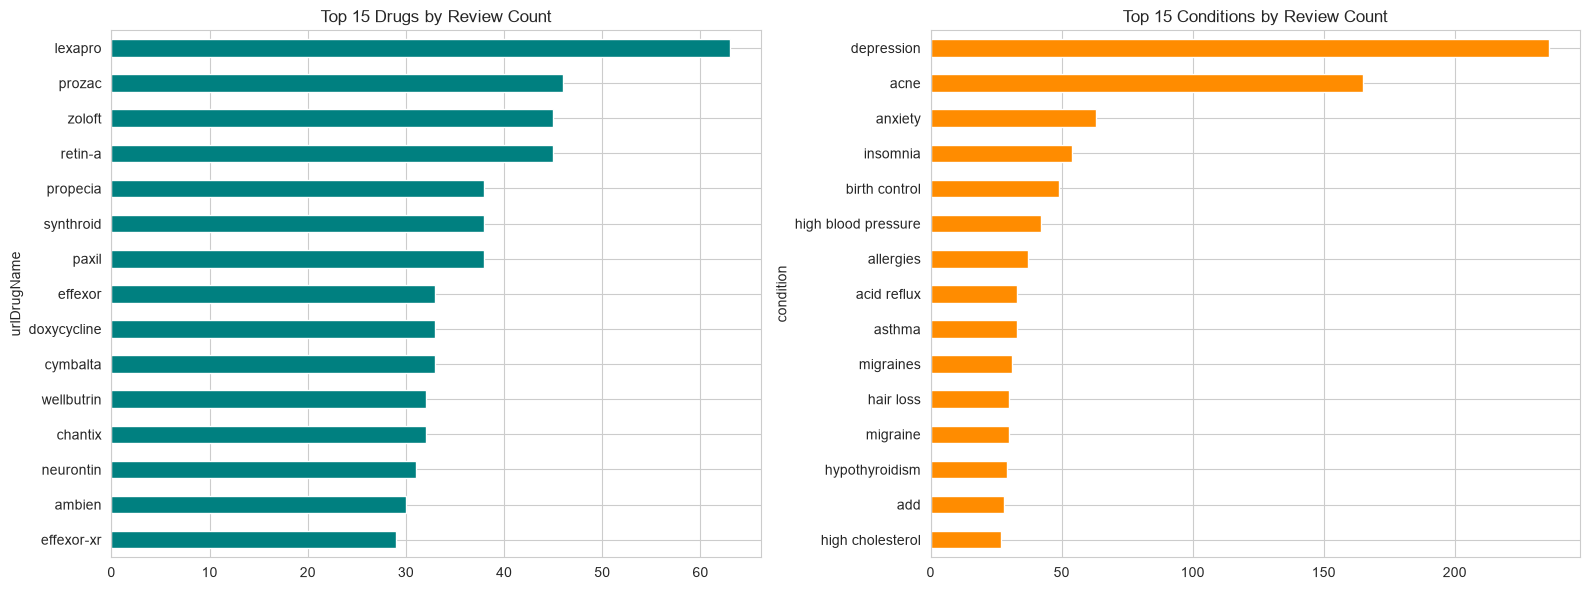

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

train_df['urlDrugName'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Drugs by Review Count')
axes[0].invert_yaxis()

train_df['condition'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Conditions by Review Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../visuals/top_drugs_conditions.png', dpi=150)
plt.show()

### Raw Word Clouds

The unprocessed word clouds are dominated with "pain", "day", "drug" and "medication". Common stopwords appeared frequently to confirm that stopword removal, lowercasing and lemmatization is required in following phases.

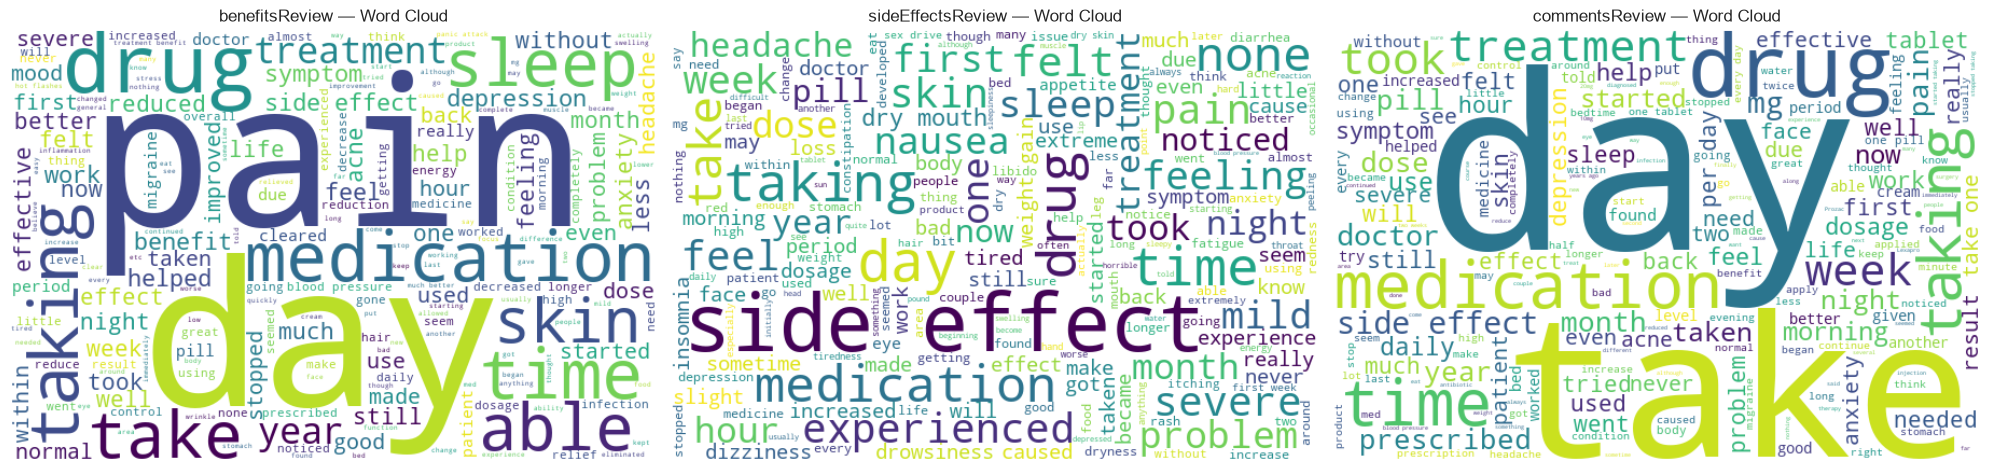

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, col in enumerate(text_cols):
    text = ' '.join(train_df[col].fillna('').astype(str).tolist())
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{col} — Word Cloud')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../visuals/wordclouds_raw.png', dpi=150)
plt.show()

### Cross-tab of Effectiveness and Side Effects
The heatmap show relationship between effectiveness and sideEffects ratings. Notably, "Highly effective" tend to cluster around "Mild Side Effects" and "No Side Effects". However, "Ineffecitve" cluster heavier on "Extremely Severe Effects" and "Sever Side Effects". This suggests there is a possible correlation between effectiveness and tolerability.

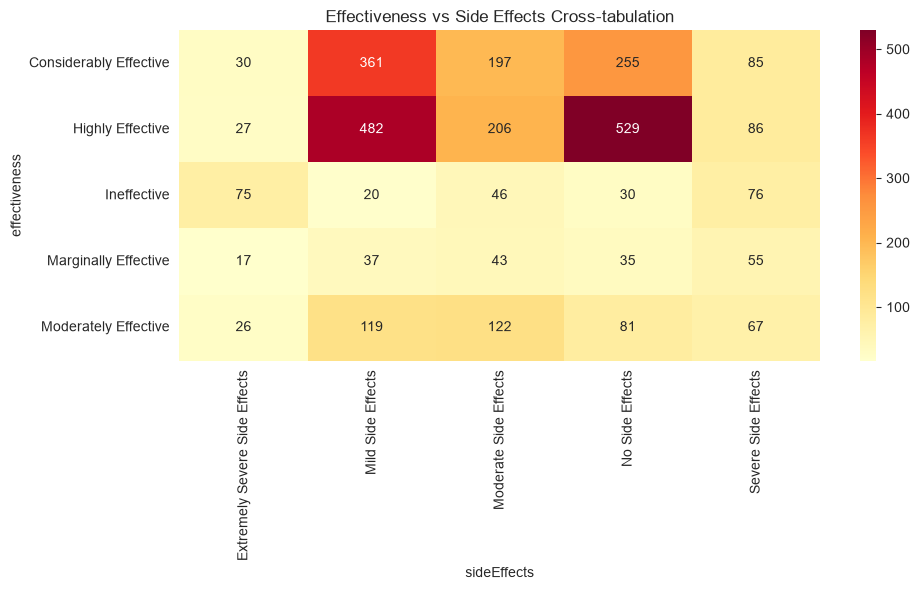

In [152]:
crosstab = pd.crosstab(train_df['effectiveness'], train_df['sideEffects'])
plt.figure(figsize=(10, 6))
sn.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Effectiveness vs Side Effects Cross-tabulation')
plt.tight_layout()
plt.savefig('../visuals/effectiveness_vs_sideeffects_heatmap.png', dpi=150)
plt.show()